# Phase 2 DoD — two agents complete one resolved interaction

**Aim:** show the Game Master / interaction skeleton end to end: two seeded agents take actions over a few ticks, a SPEAK is *resolved* into the listener's memory and the shared world tally, and the durable SQLite run log records every action, effect, and each decision's retrieval provenance (R29) — reloadable from disk (R15/R17).

Imports down from `src/polis`; nothing is redefined here.

In [1]:
from collections import Counter

import pandas as pd
from plotnine import aes, coord_flip, geom_col, ggplot, labs, theme_minimal

from polis.agent import Agent
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient
from polis.memory_seeds import EVENING_SEEDS, MORNING_SEEDS, SHARED_PERSONA, build_store
from polis.persona import Persona
from polis.runlog import RunLog
from polis.simulation import DynamicsConfig, Population, Simulation

In [2]:
# --- config: edit and re-run downward ---
TICKS = 3                      # how many interaction ticks to run
UPDATE_SCHEME = 'simultaneous' # R28: 'simultaneous' or 'sequential'
TEMPERATURE = 0.8
DB_PATH = 'phase2_run.db'      # the durable run log (SQLite) written beside this notebook

# Two agents, same neutral persona, opposite seeded memories (reused from P1) so each has
# a grounded reason to speak. Distinct ids so the world/log can tell them apart.
EVENING = Persona('evening_owner', SHARED_PERSONA.description, TEMPERATURE)
MORNING = Persona('morning_runner', SHARED_PERSONA.description, TEMPERATURE)

In [3]:
import os
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)  # fresh log each run

client = LLMClient()
embedder = EmbeddingModel()
agents = [
    Agent(EVENING, client, embedder=embedder, memory=build_store(embedder, EVENING_SEEDS)),
    Agent(MORNING, client, embedder=embedder, memory=build_store(embedder, MORNING_SEEDS)),
]
pop = Population(agents)
sim = Simulation(pop, dynamics=DynamicsConfig(update_scheme=UPDATE_SCHEME),
                 logger=RunLog.open(DB_PATH))
print('chat:', client.config.model, '| scheme:', UPDATE_SCHEME, '| agents:', pop.roster)

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17613.09it/s]

chat: qwen/qwen3-32b | scheme: simultaneous | agents: ('evening_owner', 'morning_runner')


## 1. Run the interaction

The custom tick loop (not LangGraph — R22) schedules both agents each tick: each reads its own memory, decides an action from the closed vocabulary (SPEAK a stance / ABSTAIN — R23/R25), and the Game Master resolves it deterministically (R24). A SPEAK becomes a `heard` memory in the *other* agent's store plus a world-tally increment; the speaker never writes its own memory (R2). After the run, each agent's store carries its 4 seeds plus whatever it heard.

In [4]:
run = sim.run(TICKS)
sim.log.close()

print('run_id:', run.run_id, '| config hash:', run.config_hash[:12])
for pid, ag in pop.by_id.items():
    kinds = Counter(r.kind for r in ag.memory.records)
    print(f'{pid}: {len(ag.memory)} memories  {dict(kinds)}')
print('world stance tally:')
for stance, n in pop.world.stance_tally.items():
    print(f'  {n:>2}  {stance[:60]}')

run_id: 7f730b2dfa254b1285650db14d8ecf2b | config hash: 8f6a0bdd1fb9
evening_owner: 7 memories  {'seed': 4, 'heard': 3}
morning_runner: 7 memories  {'seed': 4, 'heard': 3}
world stance tally:
   1  Adopt permanent daylight saving time (clocks stay on summer 
   5  Adopt permanent standard time (clocks stay on winter time al


## 2. The run log, reopened from disk

Durability is the point of the tier-3 substrate (R15/R17): we open a **fresh connection** to the SQLite file the run just wrote and read the whole event stream back. The event mix should be internally consistent — one `memory_write` per delivered memory, one `world_update` per tally increment, one `action` + one `retrieval` (R29) per decision, one `tick_marker` per tick.

In [5]:
reopened = RunLog.open(DB_PATH)
events = reopened.events(run.run_id)
ev = pd.DataFrame(events)
print(f'{len(ev)} events across {TICKS} ticks')
print(ev['event_type'].value_counts().to_string())

# Consistency checks against live state.
n_heard = sum(len(a.memory) - 4 for a in pop.agents)  # 4 seeds each; the rest were heard
assert (ev['event_type'] == 'memory_write').sum() == n_heard
assert (ev['event_type'] == 'world_update').sum() == sum(pop.world.stance_tally.values())
print('\nconsistent: memory_write == delivered memories, world_update == tally total')

27 events across 3 ticks
event_type
action          6
retrieval       6
memory_write    6
world_update    6
tick_marker     3

consistent: memory_write == delivered memories, world_update == tally total


### Event composition per tick

Each tick contributes the same event kinds; ABSTAIN ticks show fewer `memory_write`/`world_update` rows. Plotnine, themed minimal.

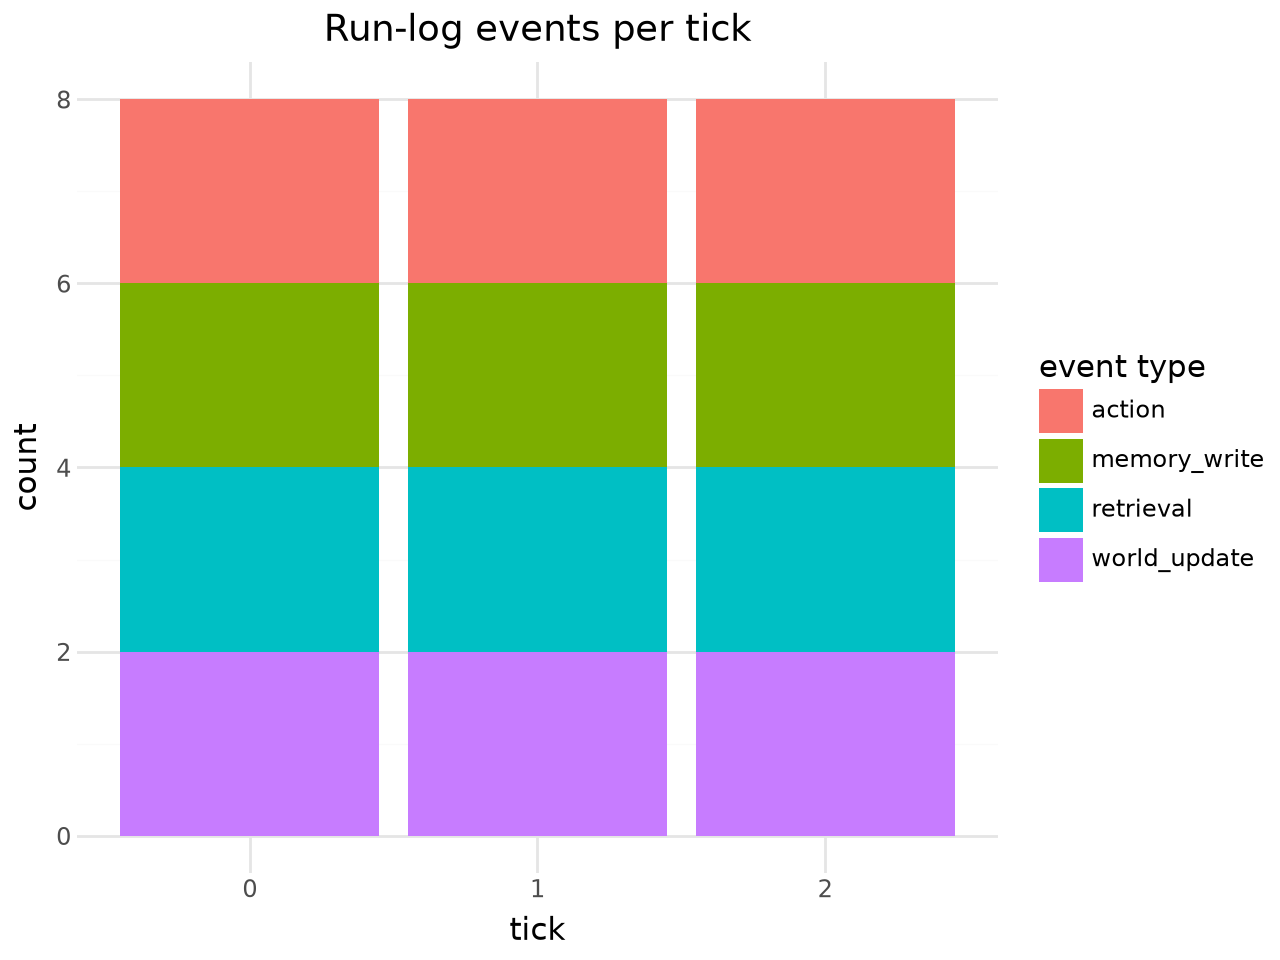

In [6]:
comp = (ev[ev['event_type'] != 'tick_marker']
        .groupby(['tick', 'event_type']).size().rename('n').reset_index())
(ggplot(comp, aes('factor(tick)', 'n', fill='event_type'))
 + geom_col()
 + labs(title='Run-log events per tick', x='tick', y='count', fill='event type')
 + theme_minimal())

## 3. Decision provenance (R29)

The mechanistic *why* behind one decision: the scored memory set that actually conditioned it, with each memory's recency / importance / relevance component and combined total — not the model's post-hoc self-reported rationale. This is the raw material for later tracing how a memory propagates into convergence.

In [7]:
prov = next(e for e in events if e['event_type'] == 'retrieval')
print(f"agent={prov['agent_id']}  tick={prov['tick']}  query={prov['payload']['query']!r}\n")
hits = pd.DataFrame(prov['payload']['hits'])
hits['memory'] = hits['text'].str.slice(0, 60) + '...'
hits[['kind', 'recency', 'importance', 'relevance', 'total', 'memory']].round(2)

agent=evening_owner  tick=0  query='daylight saving time'



,kind,recency,importance,relevance,total,memory
0,seed,0.89,1.0,1.00,2.89,I play in an after-work softball league and ga...
1,seed,1.00,1.0,0.82,2.82,The winter weeks when it's dark by 4:30pm crus...
2,seed,0.55,0.5,0.12,1.17,The best summers of my life were the ones with...
3,seed,0.00,0.0,0.00,0.00,I do all my errands and socializing after work...


## 4. What was heard — contagion into memory

Every `memory_write` is a resolved SPEAK delivered into the *listener's* private store (the only path by which one agent's output reaches another's memory — R2). These `heard` memories are the substrate the P4 topology work and P5 divergence metric will act on.

In [8]:
heard = pd.DataFrame([e['payload'] for e in events if e['event_type'] == 'memory_write'])
if len(heard):
    heard['heard'] = heard['text'].str.slice(0, 80) + '...'
    display(heard[['target_agent_id', 'kind', 'heard']])
else:
    print('both agents abstained every tick — rerun (LLM sampling) to see a SPEAK')

,target_agent_id,kind,heard
0,morning_runner,heard,a working New Yorker in your thirties with an ...
1,evening_owner,heard,a working New Yorker in your thirties with an ...
2,morning_runner,heard,a working New Yorker in your thirties with an ...
3,evening_owner,heard,a working New Yorker in your thirties with an ...
4,morning_runner,heard,a working New Yorker in your thirties with an ...
5,evening_owner,heard,a working New Yorker in your thirties with an ...


## Verdict

**DoD met.** A two-agent `Simulation` runs the tick loop and, for a resolved SPEAK: the speaker's stance lands as a `heard` memory in the *listener's* store and increments the shared world tally; every memory-write / world-update has a matching log event (no orphans); the SQLite run log records the tick's actions, effects, and an R29 retrieval-provenance event per decision; and the stream survives being reopened from disk (R15/R17). The R28 update scheme is a recorded run parameter (`config['update_scheme']`); switch `UPDATE_SCHEME` to `'sequential'` and re-run to see agent 2 retrieve agent 1's utterance within the same tick.

Deterministic coverage (no network) lives in `tests/test_runlog.py`, `test_world.py`, `test_game_master.py`, `test_simulation.py`.